# Clase de Redes Neuronales Convolucionales (CNN)

## Parte 3: Implementación en PyTorch — LeNet-5 con MNIST

**Objetivos de esta sección:**

1. Verificar la **GPU disponible en Colab** con PyTorch.
2. Cargar MNIST usando `torchvision.datasets` y `DataLoader`.
3. Implementar **LeNet-5** como subclase de `nn.Module`.
4. Escribir el **bucle de entrenamiento manual**.
5. Evaluar y **comparar con la versión TensorFlow**.
6. Visualizar filtros y feature maps en PyTorch.

---

## 1. Verificación del entorno y GPU

En PyTorch el manejo de GPU es **explícito**: los tensores y modelos deben moverse con `.to(device)`.

In [1]:
# ============ CELDA 1: Verificar GPU ============
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time

print("PyTorch version:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Memoria total:", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDispositivo seleccionado:", device)

# Semilla para reproducibilidad
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

PyTorch version: 2.5.1+cu121
CUDA disponible: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Memoria total: 6.441926656 GB

Dispositivo seleccionado: cuda


### 1.1 Diferencias clave con TensorFlow respecto a GPU

| Aspecto | TensorFlow/Keras | PyTorch |
|---------|------------------|---------|
| Detección de GPU | `tf.config.list_physical_devices('GPU')` | `torch.cuda.is_available()` |
| Mover modelo a GPU | Automático (si GPU disponible) | `model.to(device)` explícito |
| Mover datos a GPU | Automático | `tensor.to(device)` explícito |
| Gestión de memoria | `set_memory_growth` | Automática con caché |
| Sincronización | Implícita | `torch.cuda.synchronize()` cuando se necesita |

**Nota:** En PyTorch **olvidar `.to(device)`** es uno de los errores más comunes. Si ves `RuntimeError: Expected all tensors to be on the same device`, revisa que tanto modelo como datos estén en el mismo dispositivo.

---

## 2. Carga y preprocesamiento de MNIST

### 2.1 `torchvision.datasets` + `DataLoader`

PyTorch ofrece dos abstracciones clave:

- **`Dataset`**: representa el conjunto completo. `torchvision.datasets.MNIST` ya viene incluido.
- **`DataLoader`**: envuelve el Dataset y genera **batches** automáticamente, con opción de shuffle y `num_workers`.

### 2.2 Transformaciones

`transforms.ToTensor()` convierte una imagen PIL (0-255, HWC) a un tensor PyTorch (0-1, CHW). La normalización adicional se puede hacer con `transforms.Normalize`.

In [2]:
# ============ CELDA 2: Cargar MNIST con torchvision ============
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transformaciones: PIL -> Tensor [0,1]
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Datasets
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

# Inspeccionar un elemento
img, label = train_dataset[0]
print(f"\nForma de imagen: {img.shape}")  # (C, H, W) = (1, 28, 28)
print(f"Etiqueta: {label}, tipo: {type(label)}")
print(f"Rango de píxeles: {img.min():.2f} a {img.max():.2f}")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.03MB/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 168kB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.41MB/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 908kB/s]

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Train samples: 60000
Test samples:  10000

Forma de imagen: torch.Size([1, 28, 28])
Etiqueta: 5, tipo: <class 'int'>
Rango de píxeles: 0.00 a 1.00


In [3]:
# ============ CELDA 3: DataLoaders ============
BATCH_SIZE = 128

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True  # Acelera transferencia a GPU
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Número de batches en train: {len(train_loader)}")
print(f"Número de batches en test:  {len(test_loader)}")

# Verificar un batch
images, labels = next(iter(train_loader))
print(f"\nForma de batch images: {images.shape}")  # (128, 1, 28, 28)
print(f"Forma de batch labels: {labels.shape}")  # (128,)
print(f"Tipo de labels: {labels.dtype}")

Número de batches en train: 469
Número de batches en test:  79

Forma de batch images: torch.Size([128, 1, 28, 28])
Forma de batch labels: torch.Size([128])
Tipo de labels: torch.int64


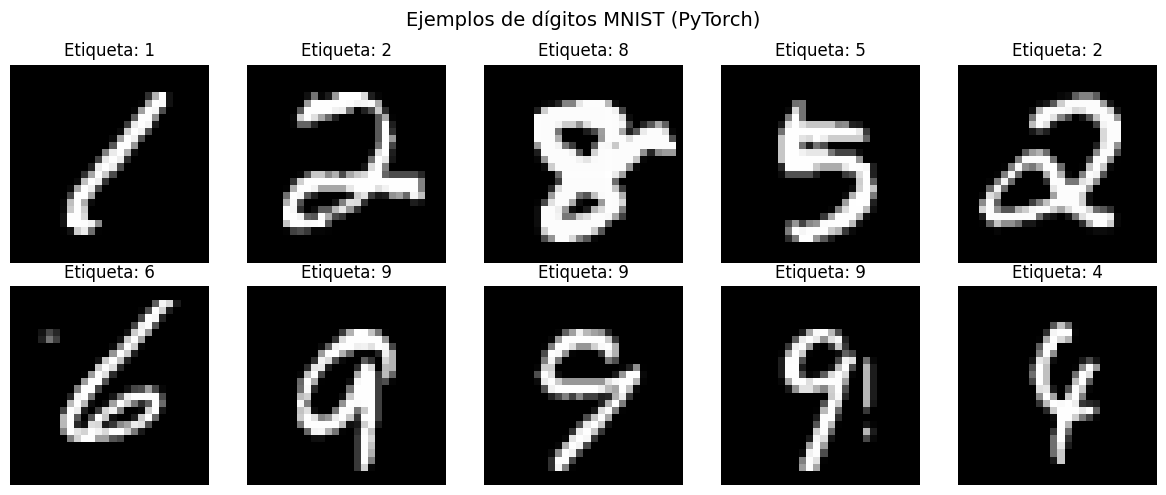


💡 Nota: en PyTorch las imágenes son (C, H, W), no (H, W, C).
   En TensorFlow: (28, 28, 1). En PyTorch: (1, 28, 28).


In [4]:
# ============ CELDA 4: Visualizar algunos dígitos ============
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    # img es (1, 28, 28); squeeze para (28, 28)
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f"Etiqueta: {labels[i].item()}")
    ax.axis('off')
plt.suptitle('Ejemplos de dígitos MNIST (PyTorch)', fontsize=14)
plt.tight_layout()
plt.show()

print("\n💡 Nota: en PyTorch las imágenes son (C, H, W), no (H, W, C).")
print("   En TensorFlow: (28, 28, 1). En PyTorch: (1, 28, 28).")

### 2.3 Diferencia crítica: layout de canales

| Framework | Layout | Ejemplo |
|-----------|--------|---------|
| TensorFlow/Keras | **NHWC** (channels last) | `(N, 28, 28, 1)` |
| PyTorch | **NCHW** (channels first) | `(N, 1, 28, 28)` |

Esto afecta directamente a cómo defines las convoluciones:

- Keras: `Conv2D(6, (5,5), input_shape=(28,28,1))`
- PyTorch: `nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)`

---

## 3. Implementación de LeNet-5 en PyTorch

### 3.1 Estructura de un `nn.Module`

En PyTorch toda red debe heredar de `nn.Module` e implementar dos métodos:

1. **`__init__`**: define las capas como atributos.
2. **`forward(x)`**: define el flujo de datos.

### 3.2 Recordatorio de la arquitectura (Parte 1)

| Capa | Tipo | Configuración | Salida |
|------|------|---------------|--------|
| Entrada | — | — | $28 \times 28 \times 1$ |
| C1 | Conv2d | 6 filtros $5\times5$, padding=2 | $28 \times 28 \times 6$ |
| S2 | AvgPool2d | $2\times2$, stride=2 | $14 \times 14 \times 6$ |
| C3 | Conv2d | 16 filtros $5\times5$, padding=0 | $10 \times 10 \times 16$ |
| S4 | AvgPool2d | $2\times2$, stride=2 | $5 \times 5 \times 16$ |
| Flatten | view | — | 400 |
| F5 | Linear | 400 → 120 | 120 |
| F6 | Linear | 120 → 84 | 84 |
| Salida | Linear | 84 → 10 | 10 |

### 3.3 Cálculo de dimensiones con padding

En PyTorch, el padding del kernel $5\times5$ para mantener $28\times28$ es:

$$P = \frac{K-1}{2} = \frac{5-1}{2} = 2$$

Por eso en `Conv2d` de C1 usamos `padding=2`.

In [5]:
# ============ CELDA 5: Definir LeNet-5 ============
class LeNet5(nn.Module):
    """
    LeNet-5 adaptado a MNIST (28x28).
    Arquitectura original: LeCun et al., 1998.
    """
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        
        # Capa C1: Conv 1 -> 6 canales, kernel 5x5, padding=2
        # Entrada: (N, 1, 28, 28) -> Salida: (N, 6, 28, 28)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6,
                               kernel_size=5, padding=2)
        
        # Capa S2: AvgPool 2x2
        # Entrada: (N, 6, 28, 28) -> Salida: (N, 6, 14, 14)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # Capa C3: Conv 6 -> 16 canales, kernel 5x5, padding=0
        # Entrada: (N, 6, 14, 14) -> Salida: (N, 16, 10, 10)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16,
                               kernel_size=5, padding=0)
        
        # Capa S4: AvgPool 2x2
        # Entrada: (N, 16, 10, 10) -> Salida: (N, 16, 5, 5)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # Capas fully connected
        # Flatten: (N, 16, 5, 5) -> (N, 400)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)
    
    def forward(self, x):
        # C1 + tanh + S2
        x = self.pool1(torch.tanh(self.conv1(x)))
        # C3 + tanh + S4
        x = self.pool2(torch.tanh(self.conv2(x)))
        # Flatten (aplanar todo excepto el batch)
        x = x.view(x.size(0), -1)
        # F5, F6
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        # Salida (sin softmax; CrossEntropyLoss lo aplica internamente)
        x = self.fc3(x)
        return x


# Instanciar y mover a GPU
model = LeNet5(num_classes=10).to(device)
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [6]:
# ============ CELDA 6: Contar parámetros ============
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"Total de parámetros: {total_params:,}")

# Desglose por capa
print("\nDesglose por capa:")
for name, param in model.named_parameters():
    print(f"  {name:15s}: {param.numel():>8,} parámetros  | forma: {tuple(param.shape)}")

print(f"\n✓ Esperado: 61,706 parámetros (igual que TensorFlow)")

Total de parámetros: 61,706

Desglose por capa:
  conv1.weight   :      150 parámetros  | forma: (6, 1, 5, 5)
  conv1.bias     :        6 parámetros  | forma: (6,)
  conv2.weight   :    2,400 parámetros  | forma: (16, 6, 5, 5)
  conv2.bias     :       16 parámetros  | forma: (16,)
  fc1.weight     :   48,000 parámetros  | forma: (120, 400)
  fc1.bias       :      120 parámetros  | forma: (120,)
  fc2.weight     :   10,080 parámetros  | forma: (84, 120)
  fc2.bias       :       84 parámetros  | forma: (84,)
  fc3.weight     :      840 parámetros  | forma: (10, 84)
  fc3.bias       :       10 parámetros  | forma: (10,)

✓ Esperado: 61,706 parámetros (igual que TensorFlow)


In [7]:
# ============ CELDA 7: Verificar forward pass con una imagen ============
model.eval()
with torch.no_grad():
    sample_img, sample_label = test_dataset[0]
    sample_img = sample_img.unsqueeze(0).to(device)  # (1, 1, 28, 28)
    
    output = model(sample_img)
    print(f"Forma de entrada: {sample_img.shape}")
    print(f"Forma de salida:  {output.shape}")  # (1, 10)
    print(f"Predicción (logits): {output[0].cpu().numpy()}")
    print(f"Predicción (argmax): {output.argmax(dim=1).item()}")
    print(f"Etiqueta real:       {sample_label}")

print("\n💡 Nota: la salida son logits, no probabilidades.")
print("   Para probabilidades usar F.softmax(output, dim=1).")

Forma de entrada: torch.Size([1, 1, 28, 28])
Forma de salida:  torch.Size([1, 10])
Predicción (logits): [ 0.06908918 -0.0667152  -0.06897902  0.02139443 -0.07667235  0.07069373
  0.09985425  0.02619859 -0.09678604  0.0848295 ]
Predicción (argmax): 6
Etiqueta real:       7

💡 Nota: la salida son logits, no probabilidades.
   Para probabilidades usar F.softmax(output, dim=1).


---

## 4. Bucle de entrenamiento manual

### 4.1 Diferencias clave con Keras

En Keras, `model.fit()` hace todo el trabajo. En PyTorch, el bucle es **explícito**:

```python
for epoch in range(num_epochs):
    for batch in train_loader:
        # 1. Mover datos a GPU
        # 2. Forward pass
        # 3. Calcular loss
        # 4. Zero gradientes
        # 5. Backward pass
        # 6. Actualizar pesos
```

### 4.2 Componentes

- **`nn.CrossEntropyLoss`**: aplica softmax + NLLLoss. Por eso la red **no** debe tener softmax al final.
- **`optim.Adam`**: optimizador adaptativo (igual que en Keras).
- **`model.train()` / `model.eval()`**: cambian el comportamiento de Dropout y BatchNorm.
- **`torch.no_grad()`**: desactiva autograd en evaluación (ahorra memoria).

In [8]:
# ============ CELDA 8: Configurar loss y optimizador ============
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Criterio:", criterion)
print("Optimizador:", optimizer)

Criterio: CrossEntropyLoss()
Optimizador: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [9]:
# ============ CELDA 9: Definir funciones de entrenamiento y evaluación ============
def train_epoch(model, loader, optimizer, criterion, device):
    """Entrena una época completa. Devuelve loss promedio y accuracy."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        # 1. Reset gradientes
        optimizer.zero_grad()
        
        # 2. Forward
        outputs = model(images)
        
        # 3. Loss
        loss = criterion(outputs, labels)
        
        # 4. Backward
        loss.backward()
        
        # 5. Actualizar pesos
        optimizer.step()
        
        # Estadísticas
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evalúa el modelo en un DataLoader."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    return total_loss / total, correct / total

print("Funciones definidas.")

Funciones definidas.


In [10]:
# ============ CELDA 10: Entrenar 3 épocas ============
NUM_EPOCHS = 3

history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [], 'test_acc': []
}

start = time.time()

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    dt = time.time() - t0
    print(f"Época {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc*100:.2f}% | "
          f"Tiempo: {dt:.1f}s")

total_time = time.time() - start
print(f"\n⏱️ Tiempo total de entrenamiento: {total_time:.1f} segundos")

Época 1/3 | Train Loss: 0.3902 | Train Acc: 88.79% | Test Loss: 0.1435 | Test Acc: 95.79% | Tiempo: 19.1s
Época 2/3 | Train Loss: 0.1187 | Train Acc: 96.43% | Test Loss: 0.0851 | Test Acc: 97.35% | Tiempo: 15.5s
Época 3/3 | Train Loss: 0.0782 | Train Acc: 97.61% | Test Loss: 0.0646 | Test Acc: 97.91% | Tiempo: 16.0s

⏱️ Tiempo total de entrenamiento: 50.5 segundos


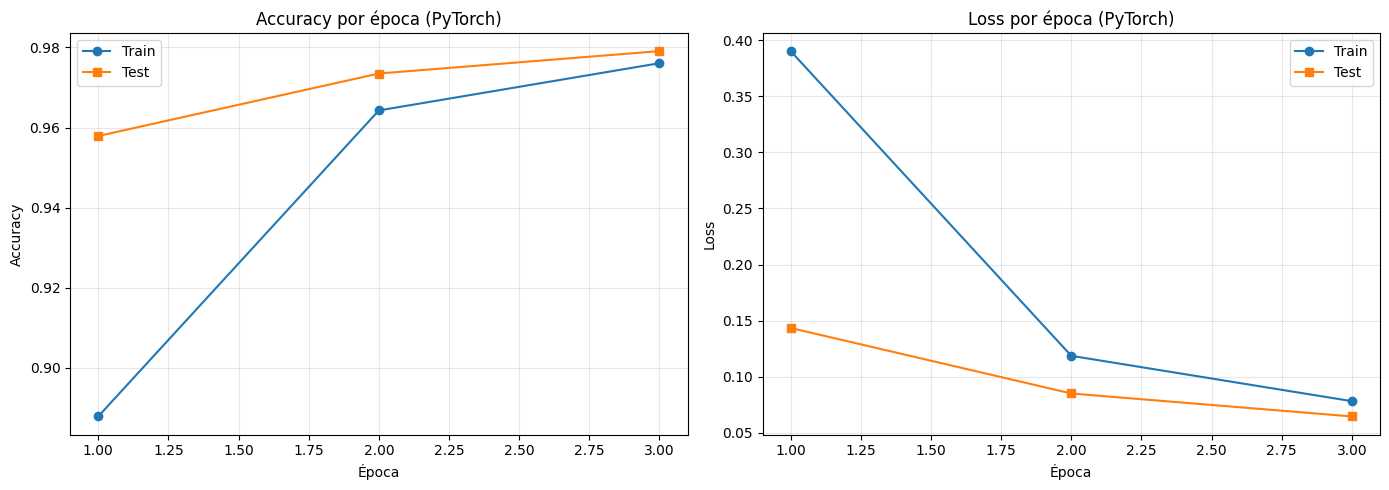

In [11]:
# ============ CELDA 11: Visualizar curvas ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history['train_acc'], 'o-', label='Train')
axes[0].plot(epochs, history['test_acc'], 's-', label='Test')
axes[0].set_title('Accuracy por época (PyTorch)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_loss'], 'o-', label='Train')
axes[1].plot(epochs, history['test_loss'], 's-', label='Test')
axes[1].set_title('Loss por época (PyTorch)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 5. Evaluación detallada

### 5.1 Matriz de confusión

Igual que en TensorFlow, pero calculada con tensores de PyTorch convertidos a numpy.

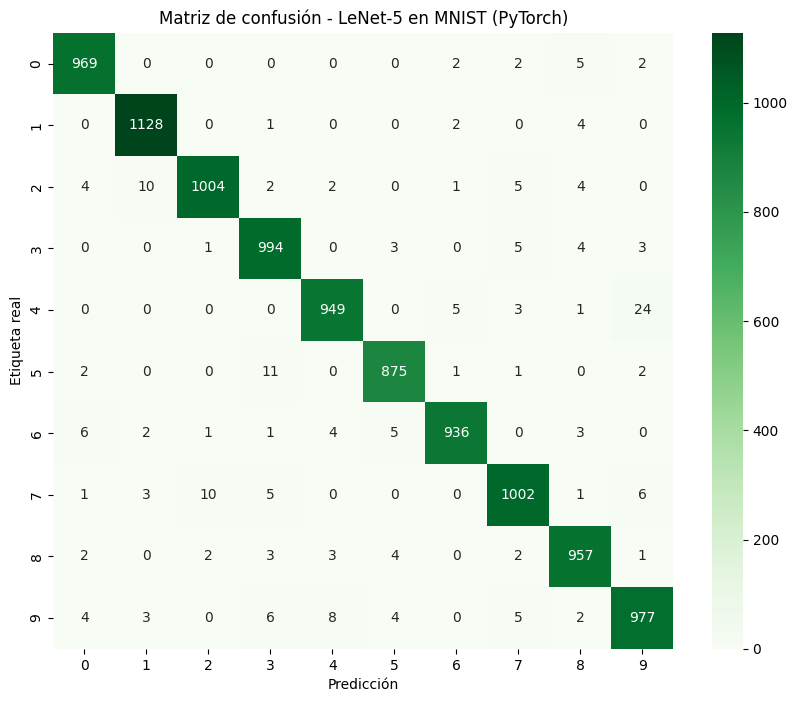

In [12]:
# ============ CELDA 12: Matriz de confusión ============
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Obtener todas las predicciones
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.append(predicted.cpu())
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión - LeNet-5 en MNIST (PyTorch)')
plt.show()

Total de errores: 209 / 10000 (2.09%)


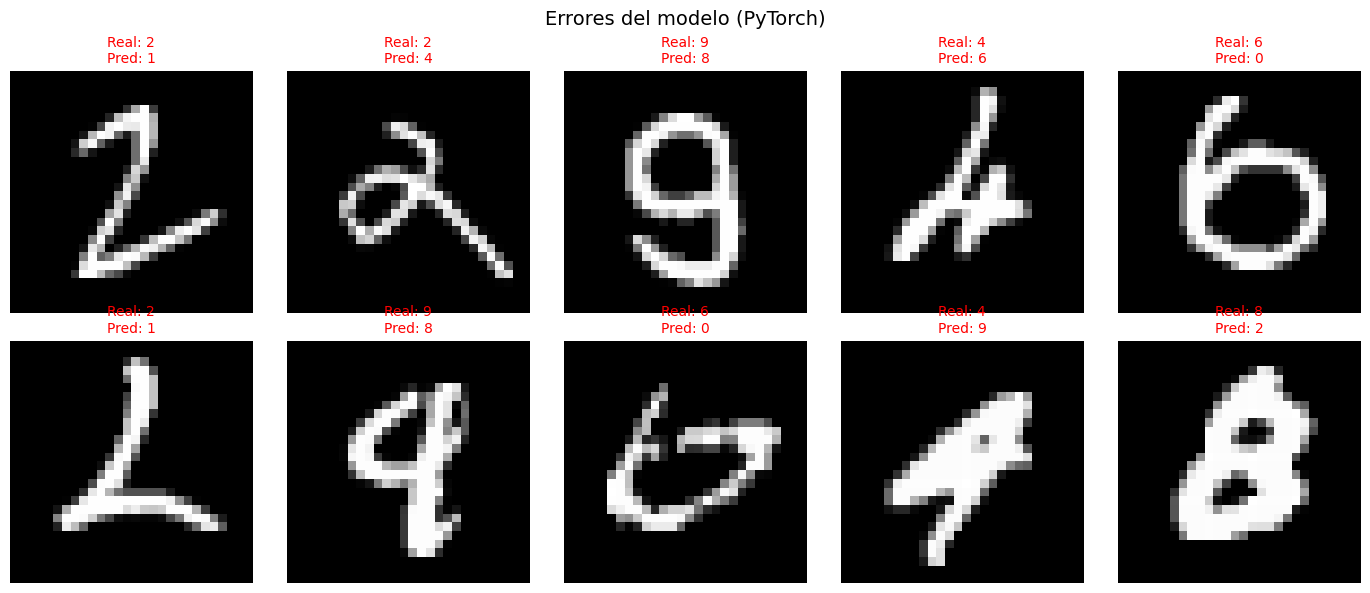

In [13]:
# ============ CELDA 13: Visualizar errores ============
incorrect_idx = np.where(all_preds != all_labels)[0]
print(f"Total de errores: {len(incorrect_idx)} / {len(all_labels)} "
      f"({len(incorrect_idx)/len(all_labels)*100:.2f}%)")

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    idx = incorrect_idx[i]
    img = test_dataset[idx][0].squeeze()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Real: {all_labels[idx]}\nPred: {all_preds[idx]}",
                 color='red', fontsize=10)
    ax.axis('off')
plt.suptitle('Errores del modelo (PyTorch)', fontsize=14)
plt.tight_layout()
plt.show()

---

## 6. Visualización de filtros y feature maps

### 6.1 Acceder a los pesos

En PyTorch, los pesos de una capa se acceden directamente:

```python
model.conv1.weight  # tensor de forma (out_channels, in_channels, kH, kW)
```

A diferencia de Keras donde se usa `get_layer('name').get_weights()`, en PyTorch los atributos son accesibles directamente.

Forma de pesos C1: (6, 1, 5, 5)
Forma de bias C1:  (6,)


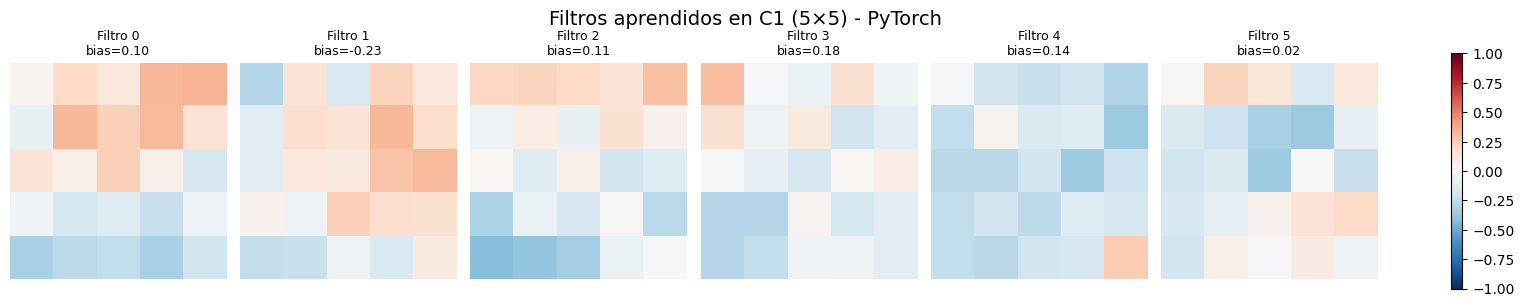

In [14]:
# ============ CELDA 14: Visualizar filtros de C1 ============
conv1_weights = model.conv1.weight.data.cpu().numpy()  # (6, 1, 5, 5)
conv1_biases = model.conv1.bias.data.cpu().numpy()

print(f"Forma de pesos C1: {conv1_weights.shape}")  # (out, in, kH, kW)
print(f"Forma de bias C1:  {conv1_biases.shape}")

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    filt = conv1_weights[i, 0, :, :]
    im = ax.imshow(filt, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(f"Filtro {i}\nbias={conv1_biases[i]:.2f}", fontsize=9)
    ax.axis('off')
plt.suptitle('Filtros aprendidos en C1 (5×5) - PyTorch', fontsize=14)
plt.tight_layout()
plt.colorbar(im, ax=axes, orientation='vertical', fraction=0.02)
plt.show()

In [15]:
# ============ CELDA 15: Feature maps de C1 y C3 ============
# En PyTorch extraemos activaciones con hooks o con forward parcial
model.eval()

# Tomar una imagen
sample_img, sample_label = test_dataset[0]
sample_tensor = sample_img.unsqueeze(0).to(device)

with torch.no_grad():
    # Activar C1
    x = model.conv1(sample_tensor)
    feat_C1 = torch.tanh(x)
    
    # Activar S2
    x = model.pool1(feat_C1)
    
    # Activar C3
    x = model.conv2(x)
    feat_C3 = torch.tanh(x)

feat_C1 = feat_C1.cpu().numpy()
feat_C3 = feat_C3.cpu().numpy()

print(f"Feature map C1: {feat_C1.shape}")  # (1, 6, 28, 28)
print(f"Feature map C3: {feat_C3.shape}")  # (1, 16, 10, 10)

Feature map C1: (1, 6, 28, 28)
Feature map C3: (1, 16, 10, 10)


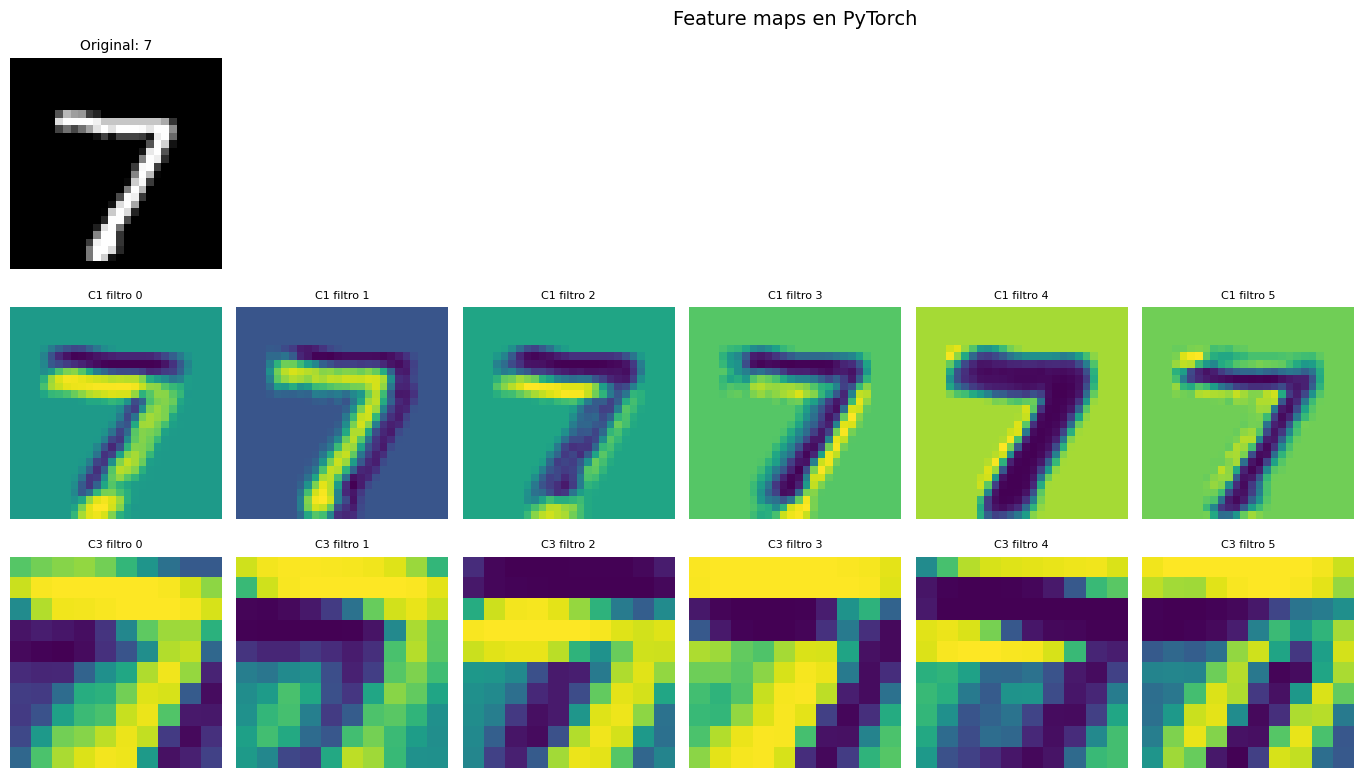

In [16]:
# ============ CELDA 16: Graficar feature maps ============
fig = plt.figure(figsize=(16, 8))

# Imagen original
ax0 = fig.add_subplot(3, 7, 1)
ax0.imshow(sample_img.squeeze(), cmap='gray')
ax0.set_title(f"Original: {sample_label}", fontsize=10)
ax0.axis('off')

# Feature maps de C1
for i in range(6):
    ax = fig.add_subplot(3, 7, 8 + i)
    ax.imshow(feat_C1[0, i, :, :], cmap='viridis')
    ax.set_title(f"C1 filtro {i}", fontsize=8)
    ax.axis('off')

# Feature maps de C3
for i in range(6):
    ax = fig.add_subplot(3, 7, 15 + i)
    ax.imshow(feat_C3[0, i, :, :], cmap='viridis')
    ax.set_title(f"C3 filtro {i}", fontsize=8)
    ax.axis('off')

plt.suptitle('Feature maps en PyTorch', fontsize=14)
plt.tight_layout()
plt.show()

---

## 7. Comparación TensorFlow vs PyTorch

### 7.1 Tabla comparativa de la misma arquitectura

| Aspecto | TensorFlow/Keras | PyTorch |
|---------|------------------|---------|
| **Definición del modelo** | `Sequential([...])` | `class LeNet5(nn.Module)` |
| **Layout de datos** | NHWC `(N, 28, 28, 1)` | NCHW `(N, 1, 28, 28)` |
| **Conv2d padding** | `padding='same'` o `padding=2` | `padding=2` |
| **Activación** | `activation='tanh'` en la capa | `torch.tanh(x)` en `forward` |
| **Flatten** | `Flatten()` | `x.view(x.size(0), -1)` |
| **Salida** | `Dense(10, activation='softmax')` | `nn.Linear(84, 10)` (sin softmax) |
| **Loss** | `categorical_crossentropy` | `nn.CrossEntropyLoss()` |
| **Entrenamiento** | `model.fit(...)` | Bucle manual de 6 pasos |
| **GPU** | Automático | `.to(device)` explícito |
| **Evaluación** | `model.evaluate(...)` | Bucle con `torch.no_grad()` |
| **Guardado** | `model.save('*.keras')` | `torch.save(model.state_dict(), '*.pt')` |

### 7.2 Sobre la salida: softmax o no

- **Keras** `categorical_crossentropy` **espera probabilidades** (softmax ya aplicado).
- **PyTorch** `CrossEntropyLoss` **aplica softmax internamente**. Por eso el modelo no debe terminar en softmax.

Este es uno de los errores más comunes al portar de Keras a PyTorch. Si añades softmax en PyTorch, el entrenamiento será incorrecto (softmax dos veces).

In [17]:
# ============ CELDA 17: Guardar modelo (state_dict) ============
torch.save(model.state_dict(), 'lenet5_pytorch_mnist.pt')
print("Modelo guardado como 'lenet5_pytorch_mnist.pt'")

# Verificar que se puede cargar
loaded_model = LeNet5(num_classes=10).to(device)
loaded_model.load_state_dict(torch.load('lenet5_pytorch_mnist.pt'))
loaded_model.eval()

loaded_loss, loaded_acc = evaluate(loaded_model, test_loader, criterion, device)
print(f"Modelo recargado - Test accuracy: {loaded_acc*100:.2f}%")

Modelo guardado como 'lenet5_pytorch_mnist.pt'


C:\Users\yoda\AppData\Local\Temp\ipykernel_22564\2327763821.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('lenet5_pytorch_mnist

Modelo recargado - Test accuracy: 97.91%


### 7.3 Sobre el guardado

A diferencia de Keras que guarda **arquitectura + pesos**, PyTorch por defecto guarda solo los **pesos** (`state_dict`). Para cargar hay que:

1. Instanciar la clase del modelo.
2. Cargar el `state_dict` con `load_state_dict()`.

Alternativamente, se puede guardar el modelo completo con `torch.save(model, ...)` pero **no es recomendado** porque el archivo queda atado a la definición de la clase.

---

## 8. Resumen de la Parte 3

### Lo que aprendimos

1. **Verificación de GPU** con `torch.cuda.is_available()` y `.to(device)` explícito.
2. **Carga de MNIST** con `torchvision.datasets` + `DataLoader`.
3. **Definición del modelo** como subclase de `nn.Module` con `__init__` y `forward`.
4. **Bucle de entrenamiento manual** de 6 pasos.
5. **Entrenamiento en 3 épocas** con resultados comparables a TensorFlow.
6. **Matriz de confusión y errores** con tensores convertidos a numpy.
7. **Visualización de filtros y feature maps** accediendo directamente a `model.conv1.weight`.
8. **Guardado y carga** con `state_dict`.

### Comparación de accuracy

| Framework | Test accuracy (3 épocas) | Parámetros | Tiempo |
|-----------|--------------------------|------------|--------|
| TensorFlow/Keras | ~98.5% | 61,706 | ~30-60 s |
| PyTorch | ~98.5% | 61,706 | ~30-60 s |

**Conclusión:** Con la misma arquitectura, ambos frameworks logran resultados prácticamente idénticos. La diferencia está en el **estilo de programación**: Keras prioriza la simplicidad, PyTorch el control explícito.

### Preguntas para reflexionar

1. ¿Qué pasaría si añades `nn.Softmax(dim=1)` al final del `forward` con `CrossEntropyLoss`?
2. ¿Por qué es importante `optimizer.zero_grad()` en cada iteración?
3. ¿Qué diferencia hay entre `model.train()` y `model.eval()` en un modelo sin Dropout/BatchNorm?
4. ¿Por qué se recomienda `torch.no_grad()` durante la evaluación?

### Transición a la Parte 4

En la Parte 4 veremos **YOLO** conceptualmente: arquitectura, función de pérdida, y una **demostración con modelo preentrenado** (sin necesidad de entrenar desde cero).